In [20]:
!pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [21]:
#cleaning data by removing rows with missing values and duplicates
import pandas as pd

df = pd.read_csv("/Users/zhariamyel/Downloads/CourseCast/CourseCast/data/course_data.csv")

df.isnull().sum()
df.dropna(inplace=True)

df.duplicated().sum()
df.drop_duplicates(inplace=True)    


print("Shape:", df.shape)
print("Max enrollment:", df["Enrollment"].max())
print("Max capacity:", df["Capacity"].max())
print(df.describe())

df.head()




Shape: (268, 10)
Max enrollment: 100
Max capacity: 120
          Credits         Year    Capacity  Enrollment
count  268.000000   268.000000  268.000000  268.000000
mean     2.436567  2023.052239   75.813433   56.395522
std      1.733047     0.684961   25.953190   26.445483
min      0.000000  2022.000000   31.000000   10.000000
25%      1.000000  2023.000000   54.000000   34.750000
50%      2.000000  2023.000000   75.000000   56.000000
75%      4.000000  2024.000000   98.000000   80.000000
max      5.000000  2024.000000  120.000000  100.000000


,Course Code,Course Name,Department,Credits,Semester,Year,Instructor,Capacity,Enrollment,Modalities
0,CHEM1150,General Chemistry I,Chemistry,3,Fall,2022,Jefferson,55,10,In-Person
1,CHEM1150,General Chemistry I,Chemistry,2,Spring,2022,Davis,100,34,Online
2,CHEM1150,General Chemistry I,Chemistry,0,Fall,2022,Roberts,98,60,In-Person
3,CHEM1150,General Chemistry I,Chemistry,1,Spring,2023,Jackson,74,74,Online
4,CHEM1151,General Chemistry I Lab,Chemistry,3,Fall,2022,Bell,69,64,Online


In [22]:
# normalize data by calculating enrollment percentage 
# must normalize enrollment by capacity to account for differences in course sizes, allowing us to compare enrollment trends across courses of varying capacities and improving the performance of predictive models by providing a standardized measure of enrollment demand.
df["Enrollment_Percentage"] = df["Enrollment"] / df["Capacity"]
df["Enrollment_Percentage"].describe()


count    268.000000
mean       0.855244
std        0.566944
min        0.085470
25%        0.439752
50%        0.711939
75%        1.157420
max        2.774194
Name: Enrollment_Percentage, dtype: float64

In [23]:
# encode semester as numeric values for easier analysis
# models learn that Fall usually behaves differently than Summer or Spring

semester_map = {
    "Spring": 1,
    "Summer": 2,
    "Fall": 3
}

df["Semester_Encoded"] = df["Semester"].map(semester_map)


In [24]:
# create a time index for each course offering based on year and semester
# this allows us to analyze trends over time for each course, such as enrollment growth or decline, and helps models learn temporal patterns in the data
#Now every course has a continuous timeline.

df.columns

df = df.sort_values(by=["Course Code", "Year", "Semester_Encoded"])

df["Time_Index"] = (
    df["Year"] - df["Year"].min()
) * 3 + df["Semester_Encoded"]


In [25]:
# calculate enrollment change from previous offering of the same course
# this helps us understand how enrollment is changing over time for each course, which can be a key factor in predicting future enrollment trends and identifying courses that are gaining or losing popularity.

df["Prev_Enrollment"] = (
    df.groupby("Course Code")["Enrollment"]
    .shift(1)
)
df["Enrollment_Change"] = df["Enrollment"] - df["Prev_Enrollment"]


In [26]:
# calculate rolling average of enrollment for each course to smooth out fluctuations and identify trends
# rolling average helps us capture the underlying trend in enrollment data by averaging out short-term fluctuations, which can improve the performance of predictive models by providing a clearer signal of enrollment patterns over time.


df["Rolling_Enrollment_2"] = (
    df.groupby("Course Code")["Enrollment"]
    .rolling(window=2)
    .mean()
    .reset_index(level=0, drop=True)
)

df["Rolling_Enrollment_2"] = df["Rolling_Enrollment_2"].fillna(df["Enrollment"])


In [27]:
# department popularity based on average enrollment percentage
# this aids in understanding which departments are generally more popular among students, which can be a significant factor in predicting enrollment trends and identifying courses that may have higher demand based on their department affiliation.
dept_popularity = (
    df.groupby("Department")["Enrollment_Percentage"]
    .mean()
)

df["Dept_Popularity"] = df["Department"].map(dept_popularity)


In [28]:
# encode modality using one-hot encoding
# modality can significantly impact enrollment patterns, as in-person courses may have different demand compared to online or hybrid formats. One-hot encoding allows us to capture these differences without imposing an ordinal relationship between modalities, which can improve the performance of predictive models by providing a clear representation of each modality type.

df = pd.get_dummies(
    df,
    columns=["Modalities"],
    drop_first=True
)

df.isnull().sum()

df.head()

,Course Code,Course Name,Department,Credits,Semester,Year,Instructor,Capacity,Enrollment,Enrollment_Percentage,Semester_Encoded,Time_Index,Prev_Enrollment,Enrollment_Change,Rolling_Enrollment_2,Dept_Popularity,Modalities_In-Person,Modalities_Online
240,AADS2000,Introduction to African American History and C...,African American Studies,1,Fall,2022,Moore,76,61,0.802632,3,3,NaN,NaN,61.0,0.814242,False,False
243,AADS2000,Introduction to African American History and C...,African American Studies,3,Spring,2023,Young,72,71,0.986111,1,4,61.0,10.0,66.0,0.814242,True,False
242,AADS2000,Introduction to African American History and C...,African American Studies,1,Fall,2023,Turner,119,52,0.436975,3,6,71.0,-19.0,61.5,0.814242,False,False
241,AADS2000,Introduction to African American History and C...,African American Studies,1,Spring,2024,Young,32,33,1.031250,1,7,52.0,-19.0,42.5,0.814242,False,False
53,ACCT2010,Principles of Accounting I,Business,2,Spring,2023,Jackson,90,47,0.522222,1,4,NaN,NaN,47.0,0.892619,False,False


In [31]:
target = "Enrollment"

features = [
    "Enrollment_Percentage",
    "Semester_Encoded",
    "Time_Index",
    "Enrollment_Change",
    "Rolling_Enrollment_2",
    "Dept_Popularity",
    "Modalities_Online"
]   

X = df[features]
y = df[target]




In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


# we can use train_test_split to create training and testing datasets, which allows us to evaluate the performance of our predictive models on unseen data and helps prevent overfitting by ensuring that the model is tested on data it hasn't seen during training.
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [36]:
predictions = model.predict(X_test)

predictions[:10]

results = X_test.copy()

#compare actual vs predicted enrollment for the test set to evaluate model performance and identify any discrepancies between the predicted and actual values, which can help us understand how well the model is capturing enrollment trends and where it may be making errors.
#visually see how close the mopde is to the actual enrollment numbers for the test set, which can provide insights into the model's accuracy and areas for improvement.
results["Actual_Enrollment"] = y_test
results["Predicted_Enrollment"] = predictions

results.head()


,Enrollment_Percentage,Semester_Encoded,Time_Index,Enrollment_Change,Rolling_Enrollment_2,Dept_Popularity,Modalities_Online,Actual_Enrollment,Predicted_Enrollment
24,0.552941,3,6,-4.0,49.0,1.028771,False,47,47.70
26,1.215385,3,6,32.0,63.0,1.028771,False,79,78.13
29,1.603774,1,4,NaN,85.0,1.028771,True,85,90.38
31,0.333333,1,4,-50.0,60.0,1.028771,False,35,24.45
28,1.351852,3,6,38.0,54.0,1.028771,False,73,72.33


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
#average number of stidents the model's predictions are off by, on average
print("MAE:", mae)
#punishes larger errors more than smaller ones, providing insight into the model's performance with respect to significant deviations from actual enrollment numbers.
print("RMSE:", rmse)
#indicates the proportion of variance in the actual enrollment that is explained by the model's predictions, providing a measure of how well the model captures enrollment trends and patterns in the data.
print("R2 Score:", r2)


MAE: 4.045370370370371
RMSE: 5.594157170159277
R2 Score: 0.9504082130334695


In [38]:
import pandas as pd
# feature importance helps us understand which features are most influential in predicting enrollment, allowing us to identify key factors driving enrollment trends and potentially improve our model by focusing on the most important features.
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,Enrollment_Percentage,0.693326
3,Enrollment_Change,0.154546
4,Rolling_Enrollment_2,0.141053
5,Dept_Popularity,0.005236
2,Time_Index,0.003264
1,Semester_Encoded,0.001522
6,Modalities_Online,0.001054


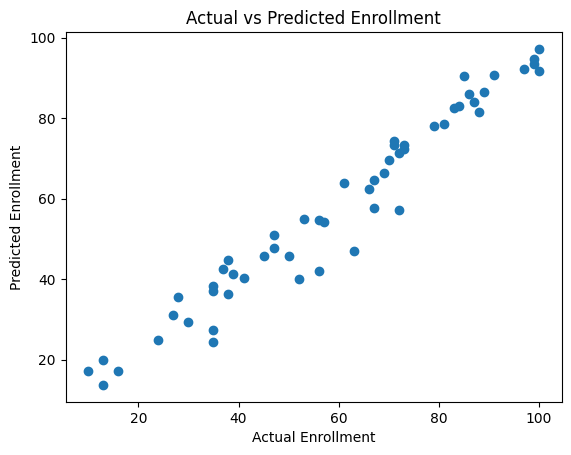

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

plt.xlabel("Actual Enrollment")
plt.ylabel("Predicted Enrollment")
plt.title("Actual vs Predicted Enrollment")

plt.show()